In [29]:
import os, sys
project_root = os.path.abspath("..")
sys.path.insert(0, project_root) # set up the working directory

In [ ]:
from pathlib import Path
import joblib

from joblib import Parallel, delayed, load
import numpy as np
import shap


import pandas as pd

import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkt

from src.models.monthly_model.monthly_climademic_model import ClimademicMonthlyModel
from functools import partial
import kmedoids
from sklearn.metrics.pairwise import euclidean_distances

In [31]:
def load_model(specie, year):
    model = ClimademicMonthlyModel()
    model_name = f"{specie}/{year}_ocsvm_{specie}_quantile_75.model'"
    model_path = Path(config["paths"]["models_directory"], model_name)
    model.load(model_path)
    return model

In [32]:
def get_explanation_sample(config, specie, year_analysis, model_year, bins, monthly_sample_size=10):

    random_seed = 43

    _columns_clima = ['t2m', 'd2m', 'tp', 'si10']
    _columns_lulc_pop = ['pop_density', 'Ocean', 'Urban',
                'Cropland', 'Pasture', 'Forest', 'Shrub',
                'Barren', 'Water']

    fname_features_global = Path(config["paths"]["processed_data"]["global_dataset"], f"{year_analysis}_global_clima_lulc_pop_res_0.25_deg.csv")
    features_global_ds = pd.read_csv(fname_features_global, low_memory=False)
    features_global_ds = features_global_ds.set_index(["longitude", "latitude"])

    monthly_samples = []
    for month in range(1, 13):
        monthly_fpath_dir = Path(config["paths"]["predictions"], f"{specie}", f"{year_analysis}")
        monthly_result_filename=str(year_analysis)+'_monthly_mean_'+str(month)+'_ocsvm_'+specie+'_predictions_'+str(model_year)+'_mod.csv'
        monthly_fpath = Path(monthly_fpath_dir, monthly_result_filename)

        prob_df = pd.read_csv(monthly_fpath)
        
        prob_df["probability_bin"] = pd.cut( prob_df["Prob_1"], bins=bins, include_lowest=True, duplicates="drop")
        #print(prob_df["probability_bin"].unique())
        prob_df = prob_df.set_index(["longitude", "latitude"])

        probability_sample = (
            prob_df.groupby("probability_bin", group_keys=False)
            .apply(
                lambda g: g.sample(
                    n=min(monthly_sample_size, len(g)),
                    random_state=random_seed + month
                )
            )
        )
        
        features_sample = features_global_ds.loc[probability_sample.index].copy()

        cols = [feat + f"_{month}" for feat in _columns_clima] + _columns_lulc_pop

        features_sample = features_sample[cols]

        features_sample = features_sample.rename(
        columns={
            f"{feat}_{month}": f"{feat}_q_0.75"
            for feat in _columns_clima
        })

        monthly_samples.append(features_sample)

    monthly_samples_unscaled = pd.concat([x for x in monthly_samples])
    return monthly_samples_unscaled

In [ ]:
def load_training_data(config, specie, year, use_cols=None):
    training_fname = f"{year}_{specie}_intermediate_training_ds.csv"
    training_fpath = Path(config["paths"]["models_directory"], f"{specie}/intermediate_training_data", training_fname)
    traing_ds = pd.read_csv(training_fpath, usecols=use_cols)
    return traing_ds

Load the config file

In [33]:
from config import load_config
config = load_config()

Pre-set / load all necessary variables

In [34]:
year_analysis = 2024
model_year = 2023
specie = "aegypti"

#load the scaler 
scaler_path = Path(config["paths"]["models_directory"], f"{specie}/scaler")
scaler = load(scaler_path)

model = load_model(specie, model_year)

In [35]:
columns_list=['t2m_q_0.75', 'd2m_q_0.75', 'tp_q_0.75', 'si10_q_0.75',
               'pop_density', 'Ocean', 'Urban',
               'Cropland', 'Pasture', 'Forest', 'Shrub',
               'Barren', 'Water']

Select the background dataset for SHAP analysis

In [36]:
X_background = load_training_data(config, specie, model_year, use_cols=columns_list)
#X_background_scaled = pd.DataFrame(scaler.transform(X_background), columns=X_background.columns)
X_background_scaled = scaler.transform(X_background)
km = kmedoids.KMedoids(n_clusters=100, method='fasterpam')
diss = euclidean_distances(X_background_scaled)
fp = kmedoids.fasterpam(diss, 100)
background = X_background_scaled[fp.medoids]

Now we need to select the explanation sample

In [37]:
bins_sample = np.linspace(0.0, 1, 11)
X_explain = get_explanation_sample(config=config,
                           specie=specie, 
                           year_analysis=year_analysis,
                           model_year=model_year,
                           bins=bins_sample,
                           monthly_sample_size = 10)

X_explain_scaled = scaler.transform(X_explain)

SHAP analysis part. It is gonne be done in parallel, to speed up the process a bit

In [38]:
def shap_predict_function(model, X):
    """
    Function passed to KernelExplainer.

    KernelSHAP supplies NumPy arrays, so this function must return
    a one-dimensional numeric array with one output per row.
    """
    X = np.asarray(X, dtype=float)

    _, _ , scores = model.predict(X, probability=False)

    return np.asarray(scores, dtype=float).reshape(-1)

In [39]:
def explain_chunk (X_chunk, background, model):
    # Each thread gets its own mutable KernelExplainer state
    predict_fn = partial(shap_predict_function, model)
    local_explainer = shap.KernelExplainer(predict_fn, background)
    return local_explainer.shap_values(X_chunk, nsamples="auto")

In [ ]:
n_jobs = 8
n_chunks = min(n_jobs, len(X_explain_scaled))


chunks = np.array_split(X_explain_scaled, n_chunks)

results = Parallel(n_jobs=n_jobs, backend="threading")(delayed(explain_chunk)(chunk, background, model) for chunk in chunks)

shap_values = np.concatenate(results, axis=0)


shap_values = np.asarray(
    shap_values,
    dtype=float
)


# Normalize possible SHAP output dimensions
if (
    shap_values.ndim == 3
    and shap_values.shape[-1] == 1
):
    shap_values = shap_values[:, :, 0]


if shap_values.shape != X_explain_scaled.shape:
    raise ValueError(
        f"Unexpected SHAP shape {shap_values.shape}; "
        f"expected {X_explain_scaled.shape}."
    )
np.save(f"{specie}_shap_values_bg_training_medoid.npy", shap_values)

After file is saed, we can use it fir future analysis

In [43]:
shap_values = np.load(f"{specie}_shap_values_bg_training_medoid.npy")
print(shap_values.shape)
feature_names = ["Temperature", "dewpoint Temperature", 'Total precipitation', 'Wind speed',
               "Population density", 'Ocean', 'Urban',
               'Cropland', 'Pasture', 'Forest', 'Shrub',
               'Barren', 'Water']
X_values = scaler.inverse_transform(X_explain_scaled)
X_values[:, 0] = X_values[:, 0] - 273.15
X_values[:, 1] = X_values[:, 1] - 273.15

shap_explanation = shap.Explanation(
    values=shap_values,
    data=X_values,  # the same feature matrix used to calculate the SHAP values
    feature_names=feature_names
)

(1200, 13)


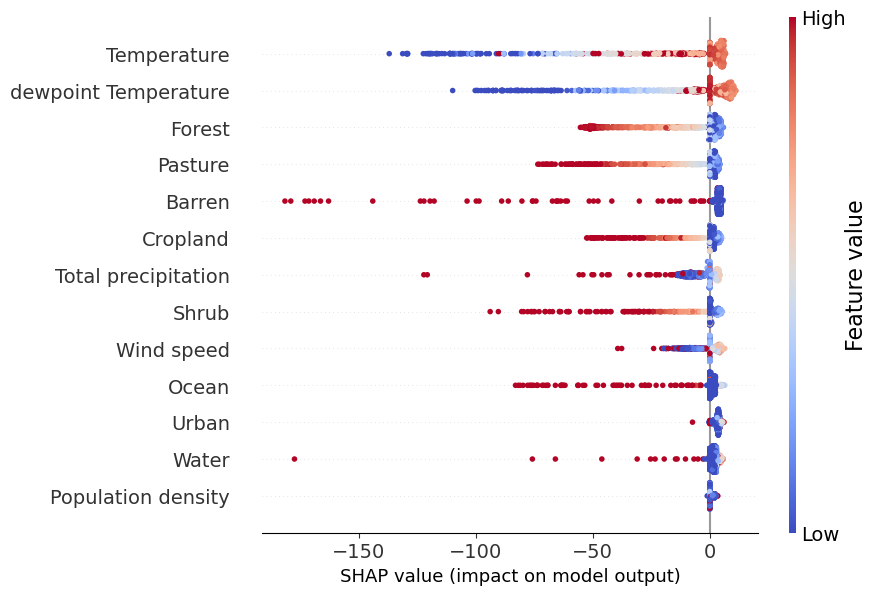

In [ ]:
importance = np.abs(shap_explanation.values).mean(axis=0)

feature_names = [
    f"[{imp:.3f}] {name}"
    for name, imp in zip(shap_explanation.feature_names, importance)
]
print(feature_names)

shap_explanation.feature_names = feature_names

ax = shap.plots.beeswarm(
    shap_explanation,
    order=shap_explanation.abs.mean(0),
    color=plt.get_cmap("coolwarm"),
    max_display=20, 
    show=False
)
ax = plt.gca()
ax.set_title(f"{specie}", fontsize=16)

for label in ax.get_yticklabels():
    label.set_ha("left")     # left-align text
    label.set_x(-0.35)       # adjust until it looks right
fig = ax.figure
ax.tick_params(axis="y", labelsize=14)   # feature names
ax.tick_params(axis="x", labelsize=14)

cbar = ax.figure.axes[-1]   # last axis is the colorbar
cbar.tick_params(labelsize=14)                 # Low/High
cbar.set_ylabel("Feature value", fontsize=16) 

plt.show()
fig.savefig(f"/Users/MalyshevaN-Dev/Documents/plot_SHAP/{specie}_SHAP_beeswarm.svg", format="svg", dpi=300, pad_inches=0)